In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
file_path = "XOR_MLP_Backprop2.xlsx"

In [4]:
excel_file = pd.ExcelFile(file_path)
print("Sheet Names:")
print(excel_file.sheet_names)
df = pd.read_excel(
    file_path,
    sheet_name="Sheet1",
    header=16
)
df = df.dropna(how="all")
print("\nDataset Shape:")
print(df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Sheet Names:
['Sheet1']

Dataset Shape:
(200, 36)

Columns:
['Epoch', 'Iter', 'x1', 'x2', 'Target', 'w11_in', 'w21_in', 'b1_in', 'w12_in', 'w22_in', 'b2_in', 'w1_in', 'w2_in', 'b3_in', 'z_h1', 'h1', 'z_h2', 'h2', 'z_y', 'y_hat', 'y_classified', 'Error', 'MSE', 'Correct?', 'delta_y', 'delta_h1', 'delta_h2', 'w11_out', 'w21_out', 'b1_out', 'w12_out', 'w22_out', 'b2_out', 'w1_out', 'w2_out', 'b3_out']

First 5 rows:
   Epoch  Iter  x1  x2  Target    w11_in    w21_in     b1_in    w12_in  \
0      1     1   0   0       0  2.500000  2.500000 -1.000000 -2.500000   
1      1     2   0   1       1  2.500000  2.500000 -1.099776 -2.500000   
2      1     3   1   0       1  2.500000  2.661331 -0.938445 -2.500000   
3      1     4   1   1       0  2.584696  2.661331 -0.853749 -2.398438   
4      2     5   0   0       0  2.571253  2.647889 -0.867192 -2.614431   

     w22_in  ...  delta_h2   w11_out   w21_out    b1_out   w12_out   w22_out  \
0 -2.500000  ... -0.005776  2.500000  2.500000 -1.099776 -

In [5]:
numeric_columns = [
    "Epoch", "Iter", "x1", "x2", "Target",
    "w11_in", "w21_in", "b1_in",
    "w12_in", "w22_in", "b2_in",
    "w1_in", "w2_in", "b3_in",
    "z_h1", "h1", "z_h2", "h2",
    "z_y", "y_hat",
    "Error", "MSE",
    "delta_y", "delta_h1", "delta_h2",
    "w11_out", "w21_out", "b1_out",
    "w12_out", "w22_out", "b2_out",
    "w1_out", "w2_out", "b3_out"
]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=["Epoch", "Iter", "MSE"])
df["Global_Iter"] = (
    (df["Epoch"] - 1) * 4 + df["Iter"]
)
print(df[["Epoch", "Iter", "Global_Iter", "x1", "x2", "Target", "MSE"]].head(10))

   Epoch  Iter  Global_Iter  x1  x2  Target       MSE
0      1     1            1   0   0       0  0.049323
1      1     2            2   0   1       1  0.155804
2      1     3            3   1   0       1  0.054641
3      1     4            4   1   1       0  0.139693
4      2     5            9   0   0       0  0.069454
5      2     6           10   0   1       1  0.129265
6      2     7           11   1   0       1  0.051115
7      2     8           12   1   1       0  0.130194
8      3     9           17   0   0       0  0.075900
9      3    10           18   0   1       1  0.118476


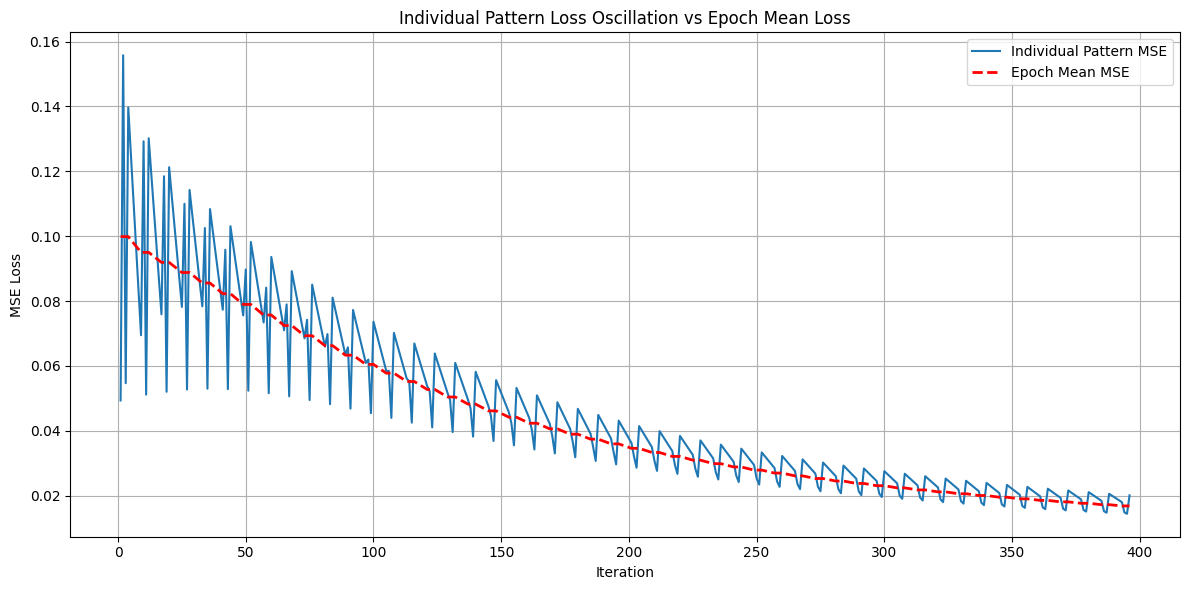

In [6]:
epoch_mean = df.groupby("Epoch")["MSE"].mean()
df["Epoch_Mean_MSE"] = df["Epoch"].map(epoch_mean)
plt.figure(figsize=(12, 6))
plt.plot(
    df["Global_Iter"],
    df["MSE"],
    label="Individual Pattern MSE",
    linewidth=1.5
)
plt.plot(
    df["Global_Iter"],
    df["Epoch_Mean_MSE"],
    "r--",
    linewidth=2,
    label="Epoch Mean MSE"
)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Individual Pattern Loss Oscillation vs Epoch Mean Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

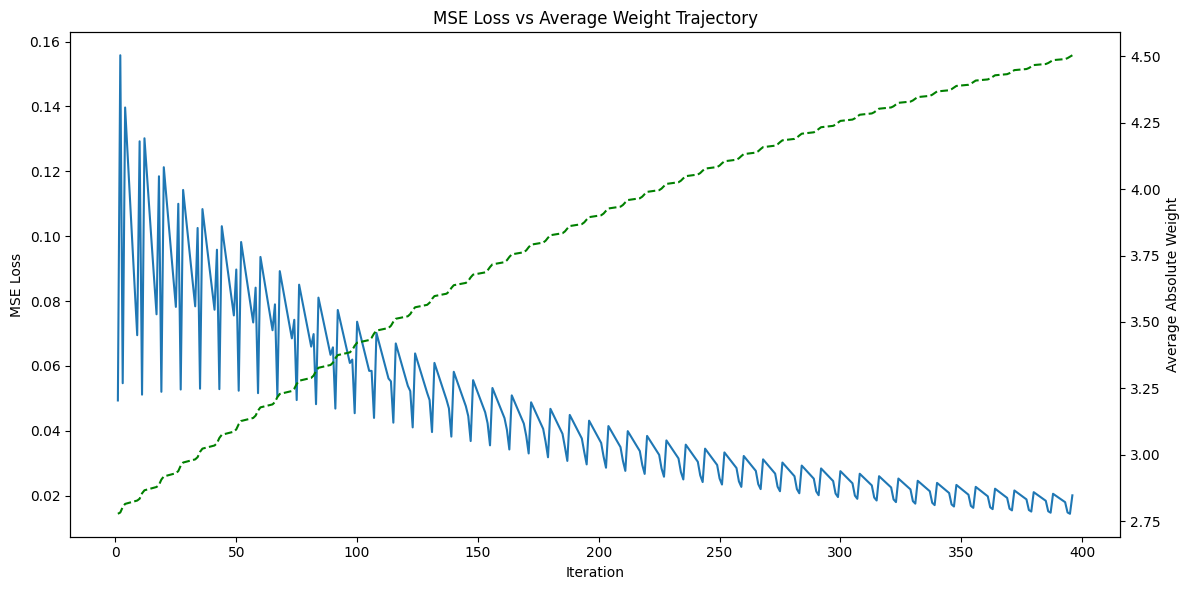

In [7]:
weight_columns = [
    "w11_in",
    "w21_in",
    "b1_in",
    "w12_in",
    "w22_in",
    "b2_in",
    "w1_in",
    "w2_in",
    "b3_in"
]
df["Average_Weight"] = df[weight_columns].abs().mean(axis=1)
fig, ax1 = plt.subplots(figsize=(12, 6))
# MSE
ax1.plot(
    df["Global_Iter"],
    df["MSE"],
    label="MSE Loss"
)
ax1.set_xlabel("Iteration")
ax1.set_ylabel("MSE Loss")
# Second Y-axis
ax2 = ax1.twinx()
ax2.plot(
    df["Global_Iter"],
    df["Average_Weight"],
    "g--",
    label="Average |Weight|"
)
ax2.set_ylabel("Average Absolute Weight")
plt.title("MSE Loss vs Average Weight Trajectory")
fig.tight_layout()
plt.show()

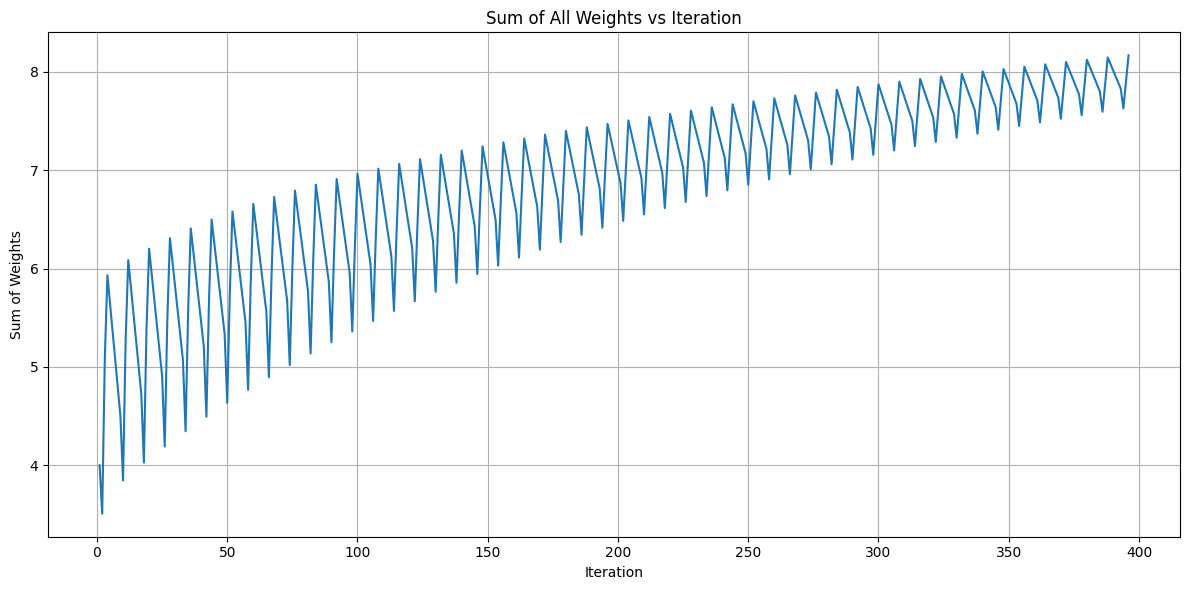

In [8]:

df["Weight_Sum"] = df[weight_columns].sum(axis=1)

plt.figure(figsize=(12, 6))

plt.plot(
    df["Global_Iter"],
    df["Weight_Sum"],
    linewidth=1.5
)

plt.xlabel("Iteration")
plt.ylabel("Sum of Weights")
plt.title("Sum of All Weights vs Iteration")

plt.grid(True)
plt.tight_layout()
plt.show()

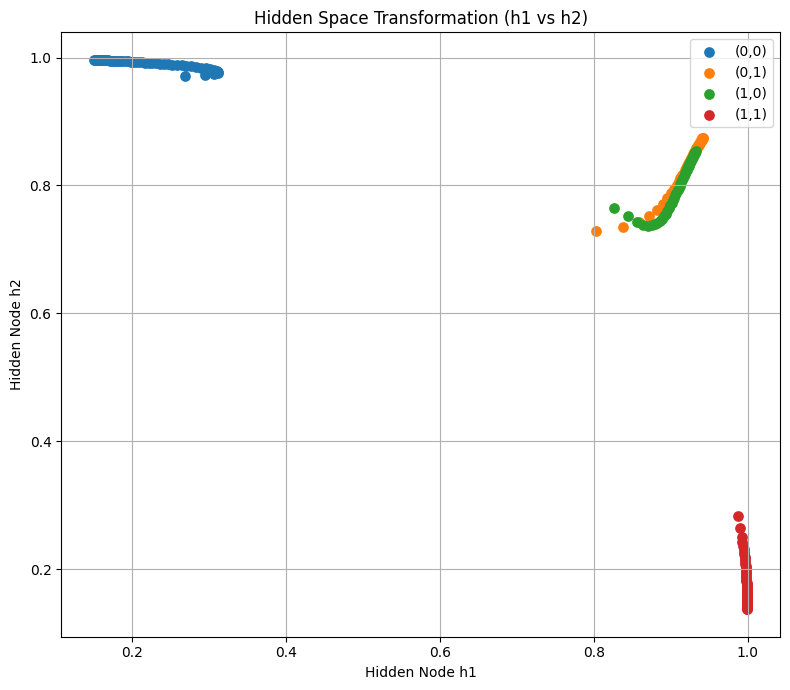

In [9]:
# ==========================================
# VISUALIZATION C
# HIDDEN SPACE TRANSFORMATION
# ==========================================
plt.figure(figsize=(8, 7))
patterns = [
    (0, 0),
    (0, 1),
    (1, 0),
    (1, 1)
]

for x1, x2 in patterns:

    subset = df[
        (df["x1"] == x1) &
        (df["x2"] == x2)
    ]

    plt.scatter(
        subset["h1"],
        subset["h2"],
        s=45,
        label=f"({x1},{x2})"
    )

plt.xlabel("Hidden Node h1")
plt.ylabel("Hidden Node h2")

plt.title("Hidden Space Transformation (h1 vs h2)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# ==========================================
# LEARNING RATE EXPERIMENT
# ==========================================

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

Y = np.array([0, 1, 1, 0], dtype=float)


def sigmoid(z):

    z = np.clip(z, -500, 500)

    return 1 / (1 + np.exp(-z))


def train_xor(eta, epochs=50):

    # Initial parameters from Excel
    w11 = 2.5
    w21 = 2.5
    b1 = -1.0
    w12 = -2.5
    w22 = -2.5
    b2 = 3.5
    w1 = 3.0
    w2 = 3.0
    b3 = -4.5
    epoch_losses = []
    weight_history = []
    for epoch in range(epochs):
        total_loss = 0
        for i in range(4):
            x1 = X[i][0]
            x2 = X[i][1]
            target = Y[i]
            zh1 = w11*x1 + w21*x2 + b1
            h1 = sigmoid(zh1)
            zh2 = w12*x1 + w22*x2 + b2
            h2 = sigmoid(zh2)
            zy = w1*h1 + w2*h2 + b3
            y_hat = sigmoid(zy)
            error = target - y_hat
            mse = 0.5 * error**2
            total_loss += mse
            delta_y = (
                error *
                y_hat *
                (1 - y_hat)
            )
            delta_h1 = (
                delta_y *
                w1 *
                h1 *
                (1 - h1)
            )

            delta_h2 = (
                delta_y *
                w2 *
                h2 *
                (1 - h2)
            )
            # UPDATE OUTPUT LAYER
            w1 += eta * delta_y * h1
            w2 += eta * delta_y * h2
            b3 += eta * delta_y
            # UPDATE HIDDEN NODE 1
            w11 += eta * delta_h1 * x1
            w21 += eta * delta_h1 * x2
            b1 += eta * delta_h1
            # UPDATE HIDDEN NODE 2
            w12 += eta * delta_h2 * x1
            w22 += eta * delta_h2 * x2
            b2 += eta * delta_h2
            # SAVE WEIGHT TRAJECTORY
            avg_weight = np.mean([
                abs(w11),
                abs(w21),
                abs(b1),
                abs(w12),
                abs(w22),
                abs(b2),
                abs(w1),
                abs(w2),
                abs(b3)
            ])
            weight_history.append(avg_weight)
        # Mean loss of current epoch
        mean_loss = total_loss / 4
        epoch_losses.append(mean_loss)
    return epoch_losses, weight_history

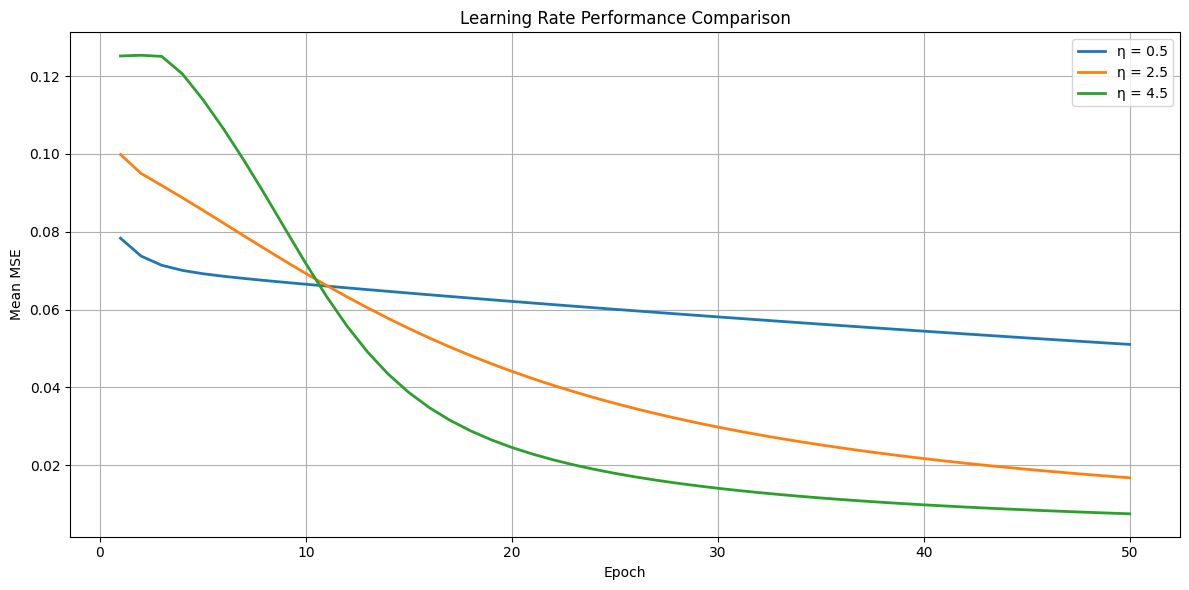

In [11]:
# ==========================================
# VISUALIZATION D
# ==========================================

learning_rates = [0.5, 2.5, 4.5]

results = {}

for eta in learning_rates:

    loss, weights = train_xor(
        eta=eta,
        epochs=50
    )

    results[eta] = {
        "loss": loss,
        "weights": weights
    }


plt.figure(figsize=(12, 6))

for eta in learning_rates:

    plt.plot(
        range(1, 51),
        results[eta]["loss"],
        linewidth=2,
        label=f"η = {eta}"
    )

plt.xlabel("Epoch")
plt.ylabel("Mean MSE")
plt.title("Learning Rate Performance Comparison")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

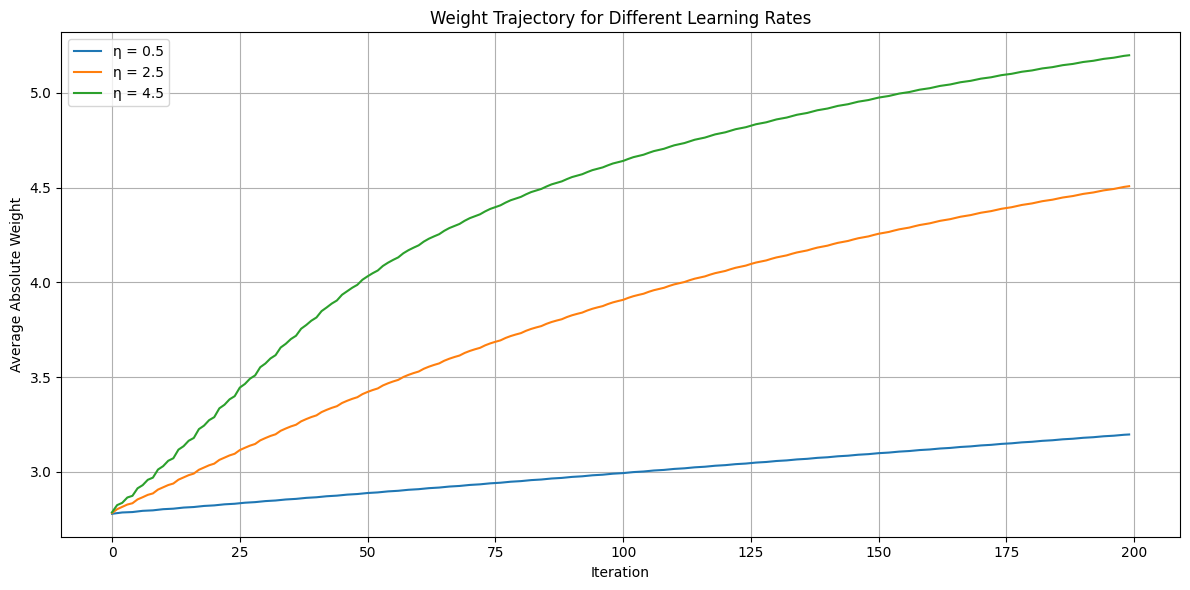

In [12]:
# ==========================================
# WEIGHT TRAJECTORY COMPARISON
# ==========================================

plt.figure(figsize=(12, 6))

for eta in learning_rates:

    plt.plot(
        results[eta]["weights"],
        label=f"η = {eta}"
    )

plt.xlabel("Iteration")
plt.ylabel("Average Absolute Weight")

plt.title("Weight Trajectory for Different Learning Rates")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# ==========================================
# FINAL RESULTS
# ==========================================

print("\nLearning Rate Results")
print("-" * 40)

for eta in learning_rates:

    final_loss = results[eta]["loss"][-1]

    print(
        f"Learning Rate η = {eta}: "
        f"Final MSE = {final_loss:.6f}"
    )


Learning Rate Results
----------------------------------------
Learning Rate η = 0.5: Final MSE = 0.051063
Learning Rate η = 2.5: Final MSE = 0.016786
Learning Rate η = 4.5: Final MSE = 0.007534


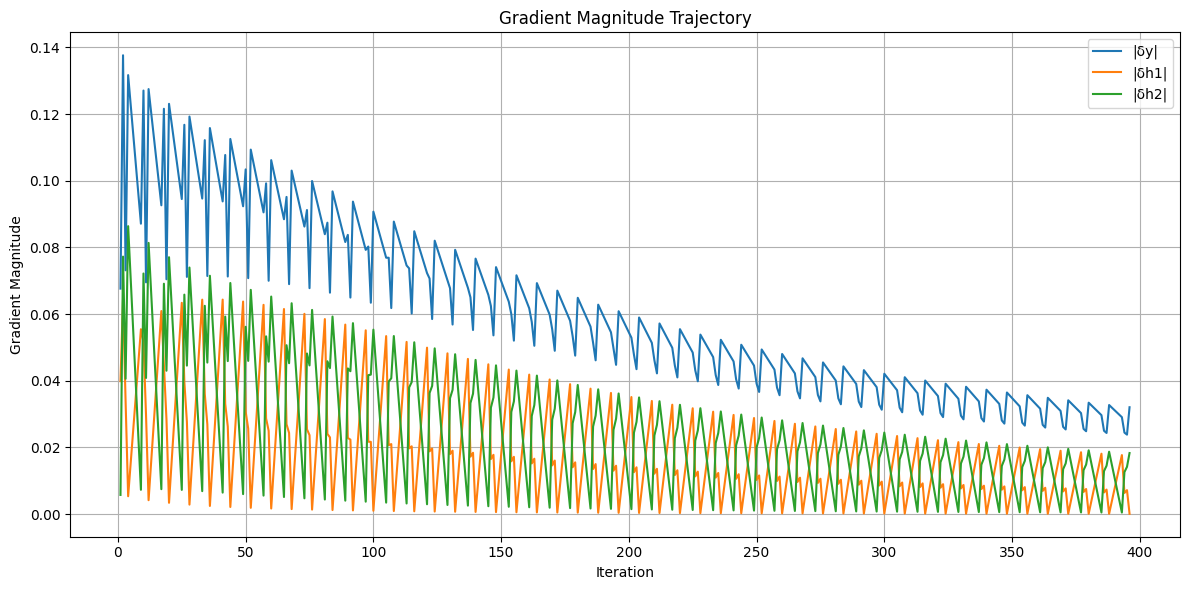

In [ ]:
# EXTENDED TASK 1
# Convert gradient columns to numeric
df["delta_y"] = pd.to_numeric(
    df["delta_y"],
    errors="coerce"
)
df["delta_h1"] = pd.to_numeric(
    df["delta_h1"],
    errors="coerce"
)
df["delta_h2"] = pd.to_numeric(
    df["delta_h2"],
    errors="coerce"
)
# Plot absolute gradient magnitudes
plt.figure(figsize=(12, 6))
plt.plot(
    df["Global_Iter"],
    df["delta_y"].abs(),
    label="|δy|",
    linewidth=1.5
)
plt.plot(
    df["Global_Iter"],
    df["delta_h1"].abs(),
    label="|δh1|",
    linewidth=1.5
)
plt.plot(
    df["Global_Iter"],
    df["delta_h2"].abs(),
    label="|δh2|",
    linewidth=1.5
)
plt.xlabel("Iteration")
plt.ylabel("Gradient Magnitude")
plt.title(
    "Gradient Magnitude Trajectory"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

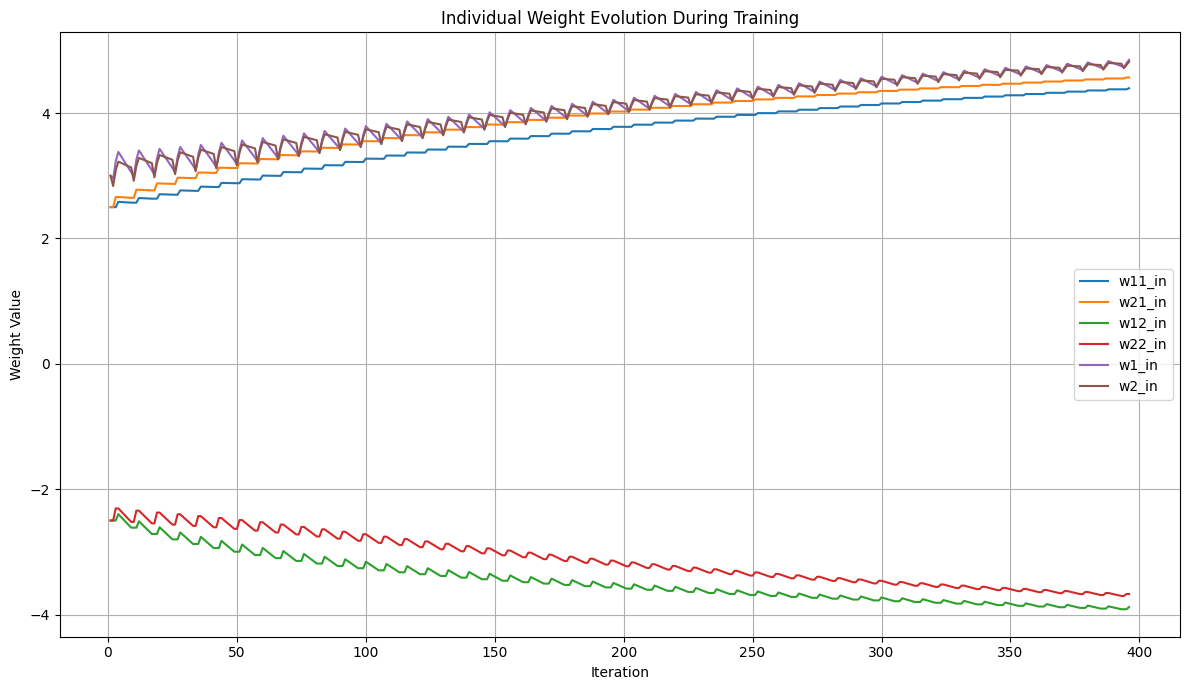

In [ ]:
# EXTENDED TASK 2
# INDIVIDUAL WEIGHT TRAJECTORIES
weight_columns = [
    "w11_in",
    "w21_in",
    "w12_in",
    "w22_in",
    "w1_in",
    "w2_in"
]
plt.figure(figsize=(12, 7))
for weight in weight_columns:

    plt.plot(
        df["Global_Iter"],
        df[weight],
        label=weight
    )
plt.xlabel("Iteration")
plt.ylabel("Weight Value")

plt.title(
    "Individual Weight Evolution During Training"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

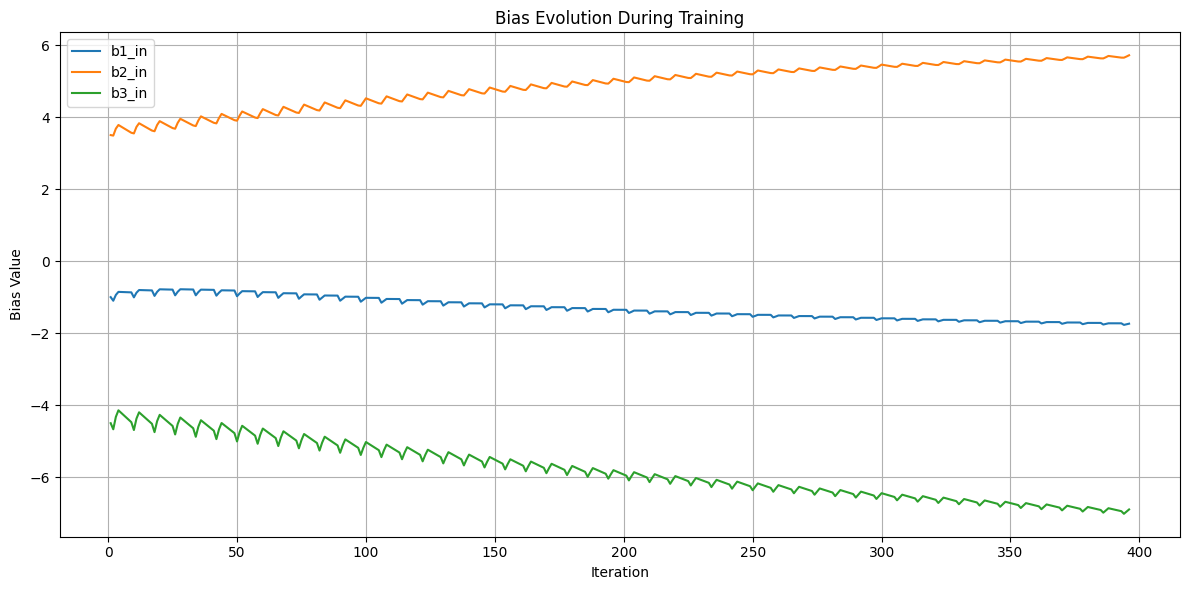

In [16]:
# INDIVIDUAL BIAS TRAJECTORIES
bias_columns = [
    "b1_in",
    "b2_in",
    "b3_in"
]
plt.figure(figsize=(12, 6))

for bias in bias_columns:

    plt.plot(
        df["Global_Iter"],
        df[bias],
        label=bias
    )
plt.xlabel("Iteration")
plt.ylabel("Bias Value")
plt.title(
    "Bias Evolution During Training"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

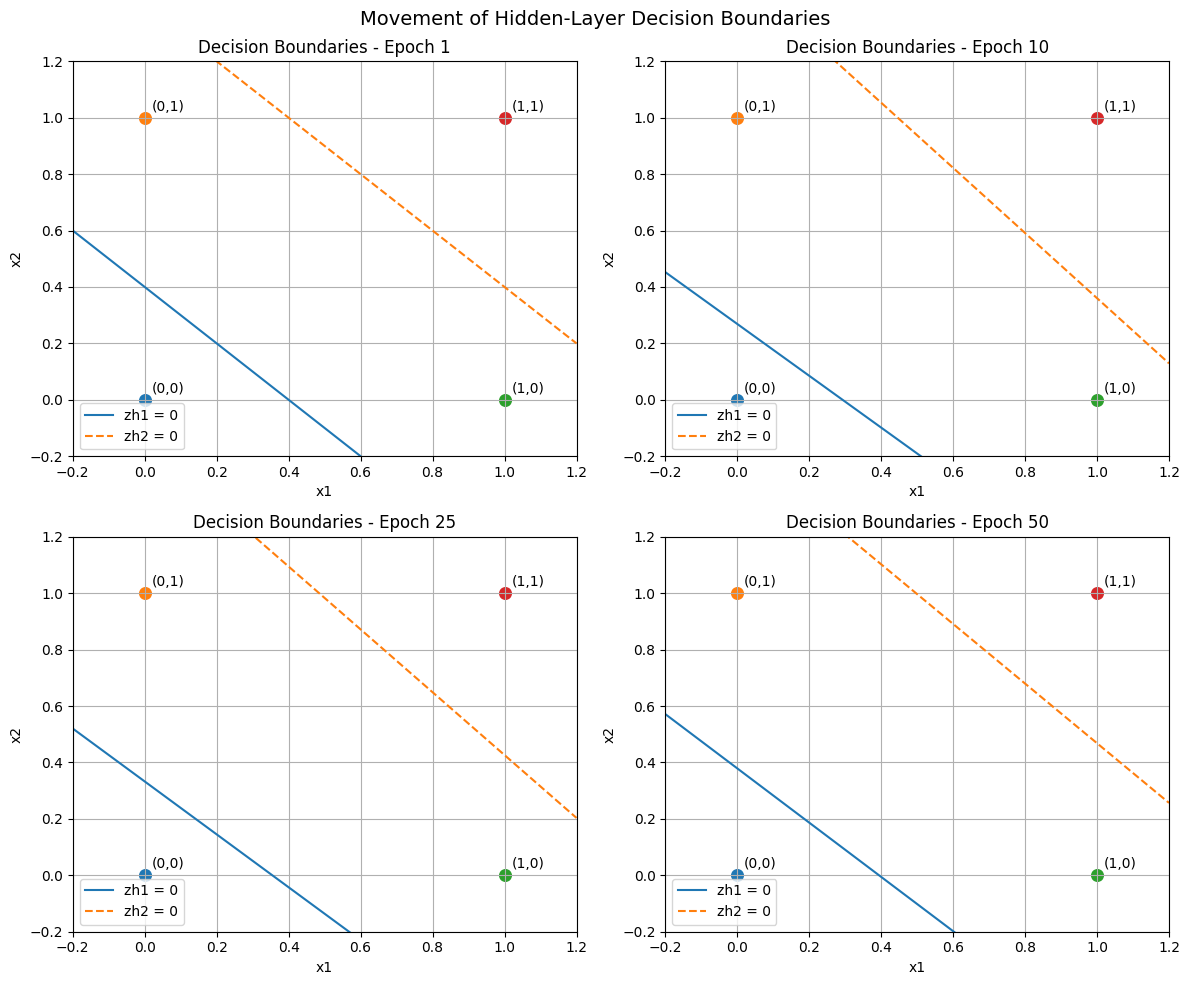

In [ ]:
# EXTENDED TASK 3
# DECISION BOUNDARY MOVEMENT
selected_epochs = [
    1,
    10,
    25,
    50
]
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10)
)
axes = axes.flatten()
for ax, epoch in zip(
    axes,
    selected_epochs
):
    # Get first iteration of selected epoch
    epoch_data = df[
        df["Epoch"] == epoch
    ]
    row = epoch_data.iloc[0]
    # Extract weights and biases
    w11 = row["w11_in"]
    w21 = row["w21_in"]
    b1 = row["b1_in"]
    w12 = row["w12_in"]
    w22 = row["w22_in"]
    b2 = row["b2_in"]
    x1_values = np.linspace(
        -0.2,
        1.2,
        100
    )
    # Boundary h1
    # zh1 = 0
    if abs(w21) > 1e-10:
        x2_h1 = (
            -(w11 * x1_values + b1)
            / w21
        )
        ax.plot(
            x1_values,
            x2_h1,
            label="zh1 = 0"
        )
    # Boundary h2
    # zh2 = 0
    if abs(w22) > 1e-10:

        x2_h2 = (
            -(w12 * x1_values + b2)
            / w22
        )
        ax.plot(
            x1_values,
            x2_h2,
            "--",
            label="zh2 = 0"
        )
    # XOR input points
    x_points = [0, 0, 1, 1]
    y_points = [0, 1, 0, 1]
    labels = [
        "(0,0)",
        "(0,1)",
        "(1,0)",
        "(1,1)"
    ]
    for x, y, label in zip(
        x_points,
        y_points,
        labels
    ):
        ax.scatter(
            x,
            y,
            s=70
        )
        ax.annotate(
            label,
            (x, y),
            xytext=(5, 5),
            textcoords="offset points"
        )
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, 1.2)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(
        f"Decision Boundaries - Epoch {epoch}"
    )
    ax.grid(True)
    ax.legend()
plt.suptitle(
    "Movement of Hidden-Layer Decision Boundaries",
    fontsize=14
)
plt.tight_layout()
plt.show()